# Full-raster chip dataset

Create a training dataset from **one complete crater-label GPKG and one WAC/NAC imagery product**. No separate training-AOI file is needed: cover the source raster with non-overlapping 256×256 native-pixel windows, dropping incomplete right/bottom windows. Empty-label chips warn but remain in the dataset. Confirm the entire raster was annotated; absence of crater outlines is otherwise not a reliable negative label.

For another label file, rerun the notebook into a new output directory. Users may extend this notebook for multiple label files, but must preserve per-source grids, selectors, label association and globally unique IDs.

Full-raster processing can be expensive, especially NAC + 63 static bands. Run cells in order to inspect the plan before creation; **Run All creates the dataset**.


In [1]:
%load_ext autoreload
%autoreload 2

from datetime import datetime
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
import json
from collections import Counter

repo_root = Path(str(Path.cwd().parent).replace(
    "/panfs/ccds02/nobackup", "/explore/nobackup"
))
if not (repo_root / "lfm").exists() or not (repo_root / "lfm/data_processing").exists():
    raise FileNotFoundError("Run from the repository's top-level notebooks/ directory.")
sys.path.insert(0, str(repo_root))

from lfm.data_processing.chip import (
    AcquisitionGroupConfig,
    ChipConfig,
    GeographicAOI,
    LabelInput,
    NoSplitConfig,
    OutputModalityConfig,
    SourceSelector,
    chip_request_from_aoi,
    create_chips,
)
from lfm.data_processing.tiling import (
    DEFAULT_RASTER_GLOBS,
    TileConfig,
    TileSourceConfig,
    VectorIndexBuildConfig,
    ensure_vector_index,
    resolve_notebook_source_index,
    discover_raster_paths,
)
from lfm.data_processing.tiling.product_ids import lunar_product_id_from_raster_path
from lfm.data_processing.tiling import make_static_source
from lfm.data_processing.chip.chip_notebook_utils import latest_crater_label_path, notebook_index_workers, plot_chip_result, read_source_grid

print(f"Repository root: {repo_root}")
from lfm.data_processing.chip import SimpleSplitConfig, SplitPercentages
from lfm.data_processing.chip.chip_dataset import plan_raster_chips
from lfm.data_processing.chip.chip_splits import plan_splits
from lfm.data_processing.chip.chip_requests import geographic_query_parts, chip_grid_family
from lfm.data_processing.tiling.grid_registry import GridFamily


Repository root: /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm


## 1. Configure the source and labels

Variables follow code order:

- `PROJECT_DATA_DIR`: shared project data root.
- `MODALITY`: `"wac"` or `"nac"`; source metadata supplies the native resolution.
- `INCLUDE_STATIC`: append 63 canonical static bands.
- `STATIC_DATA_DIR`: inspected only when static is enabled.
- `OUTPUT_BASE_DIR`: each run gets a new directory beneath `notebooks/outputs/`.
- `SOURCE_RASTER`: full original WAC VIS (5-band) or NAC (1-band) raster. WAC requires its UV companion.
- `LABEL_PATH`: finished full-scene crater GPKG, explicitly selected for this raster.
- `LABEL_LAYER`: crater feature layer.
- `BLOCK_SIZE_CHIPS`: square spatial block side in chips; 4 means 4×4 chips per block.
- `SPLIT_CONFIG`: seeded 80% train / 10% validation / 10% test assignment of whole blocks.
- `OVERWRITE`: allow replacement of this run's sample outputs when rerunning creation.
- `INSPECTION_SAMPLES`: maximum pairs with 100% valid dynamic bands to plot (static gaps are allowed). Imagery uses band 0 in grayscale.


In [2]:
PROJECT_DATA_DIR = Path("/explore/nobackup/projects/lfm")
MODALITY = "wac"  # "wac" or "nac"; rerun all cells after changing.
INCLUDE_STATIC = True  # Use False for the first NAC-only validation.
STATIC_DATA_DIR = PROJECT_DATA_DIR / "staticLinks"
OUTPUT_BASE_DIR = repo_root / "notebooks/outputs/chip_dataset"

if MODALITY == "wac":
    SOURCE_RASTER = PROJECT_DATA_DIR / "processed_data/Lunar/LRO_WAC_Pho_Sites/M1412665711CE.prj.vis.mos.tif"
    LABEL_PATH = Path(
        "/explore/nobackup/projects/lfm/example_notebook_inputs/"
        "M1412665711CE.prj.vis.mos_label_craters.gpkg"
    )  # Finished labels for this study area.
elif MODALITY == "nac":
    SOURCE_RASTER = PROJECT_DATA_DIR / "Benchmarks/Craters/NAC_PHO_E064S3160/NAC_DTM_NEWCRATER6_M1219245090_80CM.TIF"
    LABEL_PATH = Path(
        "/explore/nobackup/projects/lfm/example_notebook_inputs/"
        "NAC_DTM_NEWCRATER6_M1219245090_80CM_label_craters.gpkg"
    )  # Finished labels for this study area.
else:
    raise ValueError("MODALITY must be 'wac' or 'nac'.")

LABEL_LAYER = "craters"
BLOCK_SIZE_CHIPS = 4  # Keep each 4x4 group of neighboring chips in one split.
SPLIT_CONFIG = SimpleSplitConfig(
    percentages=SplitPercentages(train=0.8, val=0.1, test=0.1),
    seed=42, group_key_policy="request",  # Requests carry spatial-block keys, not product-only keys.
    assignment_method="count_aware",  # Target chip counts while keeping every block intact.
)
OVERWRITE = True
INSPECTION_SAMPLES = 3


### How the default split works

Each spatial block goes wholly into training, validation, or test. The fixed seed makes its assignment reproducible. The target is **80% training, 10% validation and 10% test**; count-aware assignment balances chip totals while keeping blocks intact. Each nonzero split receives at least one block when enough unlocked blocks exist. Actual percentages are approximate because blocks are indivisible; insufficient independent blocks produce a warning.

Neighbors within a block cannot enter different splits. Neighbors across block boundaries can; this is **not a spatial buffer** and does not guarantee that a large crater never crosses splits. Choose a block size appropriate for crater sizes and scientific independence. Changing the seed, block size, chip size, product identity or set of windows can change assignments. Use a prior manifest to lock existing membership when extending a dataset. Failed samples can also change published proportions.

For percentage, fixed-count, mixed count/percentage and no-split alternatives, see [Dataset contribution: split configuration](../docs/dataset_contribution.md#chip-creation-split-configuration).


## 2. Plan exact native windows and preview splits

Source metadata determines `source_grid`; it is never resized to fit labels. Each request keeps its exact pixel window, while its transformed geographic envelope selects tiles. IDs use `<product>_r<row>_c<column>`, with zero-based native-pixel offsets. Nonrectangular (sheared) pixel lattices are rejected.

Only windows entirely inside the source raster's valid mask are retained: every source band must have valid, finite pixels throughout. WAC planning checks the selected VIS raster; the final visualization also checks UV. Rejected windows are counted before splitting. Advanced users can additionally pass a native-grid Boolean `valid_mask` to the planner (True = valid). Static coverage does not restrict planning.

`plan` reports retained windows, mask rejections and omitted edge pixels. `split_plan` previews assignments; the same configuration is used by creation. The preview is saved beside the eventual manifest, including block membership and grid provenance. No chips are created yet.


In [3]:
LABEL_PATH = Path(LABEL_PATH)
if LABEL_PATH.suffix.lower() != ".gpkg":
    raise ValueError("This workflow requires a finished full-scene label GPKG.")

DYNAMIC_DATA_DIR = SOURCE_RASTER.parent
PRODUCT_ID = lunar_product_id_from_raster_path(SOURCE_RASTER)  # Same resolver as tiling.
GROUP_NAME = f"{MODALITY}_grid"
ZOOM_LEVEL = 11 if MODALITY == "nac" else 5  # Acquisition only; output keeps native grid.
INDEX_CACHE_DIR = OUTPUT_BASE_DIR / "indexes"
LOCATION_FIELD = "location"
RUN_ID = datetime.now().strftime("%Y%m%dT%H%M%S_%f")
OUTPUT_ROOT = OUTPUT_BASE_DIR / RUN_ID

for path in (SOURCE_RASTER, LABEL_PATH):
    if not path.is_file():
        raise FileNotFoundError(path)
if INCLUDE_STATIC and not STATIC_DATA_DIR.is_dir():
    raise FileNotFoundError(STATIC_DATA_DIR)
if OUTPUT_ROOT.exists():
    raise FileExistsError(f"Refusing to reuse output directory: {OUTPUT_ROOT}")
source_grid = read_source_grid(SOURCE_RASTER, expected_band_count=1 if MODALITY == "nac" else 5)


plan = plan_raster_chips(
    source_grid, product_id=PRODUCT_ID,
    source_raster=SOURCE_RASTER,  # Reject windows containing any invalid source pixel.
    label_input=LabelInput(LABEL_PATH, kind="vector_instance", layer=LABEL_LAYER, relation="clip_to_target"),
    source_selectors=(SourceSelector(GROUP_NAME, MODALITY, PRODUCT_ID),),
    block_size_chips=BLOCK_SIZE_CHIPS,  # Uses the backend's 256-pixel chip default.
)
requests = plan.requests
if any(chip_grid_family(part) != GridFamily.LTM
       for request in requests for part in geographic_query_parts(request.geographic_aoi)):
    raise ValueError("This notebook uses LTM acquisition; use the polar workflow for polar windows.")
split_plan = plan_splits(requests, SPLIT_CONFIG)
counts = Counter(item.assigned_split for item in split_plan.assignments)
print(f"Complete chips: {len(requests)} | blocks: {len({r.split_group_key for r in requests})}")
print(f"Rejected source-mask windows: {plan.rejected_mask_windows}")
print(f"Dropped rows/columns: {plan.dropped_rows}/{plan.dropped_columns}; pixels: {plan.dropped_pixels}")
print("Planned chip counts:", dict(counts))
if any(counts.get(name, 0) == 0 for name in ("train", "val", "test")):
    warnings.warn("At least one split is empty. Review block size and available independent coverage.")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=False)
preview = {
    "source_raster": str(SOURCE_RASTER), "label_path": str(LABEL_PATH),
    "source_grid": source_grid.to_dict(), "chip_size": plan.chip_size, "block_size_chips": BLOCK_SIZE_CHIPS,
    "seed": SPLIT_CONFIG.seed, "assignment_method": SPLIT_CONFIG.assignment_method,
    "percentages": {name: getattr(SPLIT_CONFIG.percentages, name) for name in ("train", "val", "test")},
    "dropped_rows": plan.dropped_rows, "dropped_columns": plan.dropped_columns,
    "dropped_pixels": plan.dropped_pixels, "planned_counts": dict(counts),
    "rejected_mask_windows": plan.rejected_mask_windows,
    "assignments": [vars(item) for item in split_plan.assignments],
}
(OUTPUT_ROOT / "window_plan.json").write_text(json.dumps(preview, indent=2) + "\n")
print("Run directory:", OUTPUT_ROOT)


/tmp/ipykernel_4100457/2197480647.py:24: UserWarning: Dropping incomplete windows: 247 bottom rows, 6 right columns (525514 pixels total, corner counted once).
  plan = plan_raster_chips(
/usr/local/lib/python3.12/dist-packages/osgeo/osr.py:410: FutureWarning: Neither osr.UseExceptions() nor osr.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Complete chips: 113 | blocks: 19
Rejected source-mask windows: 258
Dropped rows/columns: 247/6; pixels: 525514
Planned chip counts: {'train': 91, 'test': 10, 'val': 12}
Run directory: /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/chip_dataset/20261008T094736_695696


/tmp/ipykernel_4100457/2197480647.py:24: UserWarning: Rejected 258 complete windows outside the valid source mask.
  plan = plan_raster_chips(


## 3. Prepare indexes and configure acquisition

Reuse read-only shared indexes; custom collections use a per-clone cache. WAC output order is VIS 0–4, UV 5–6, then static; NAC contributes one band, then static. Known uncovered bands remain -32768 with warnings.

`chip_config` uses the spatial-block split configuration from above. Index workers and chip workers do not run concurrently.


In [4]:
DYNAMIC_INDEX_RESOLUTION = resolve_notebook_source_index(
    source_name=MODALITY, data_dir=DYNAMIC_DATA_DIR, cache_dir=INDEX_CACHE_DIR
)
STATIC_INDEX_RESOLUTION = resolve_notebook_source_index(
    source_name="static", data_dir=STATIC_DATA_DIR, cache_dir=INDEX_CACHE_DIR
) if INCLUDE_STATIC else None
DYNAMIC_INDEX = DYNAMIC_INDEX_RESOLUTION.index_path
STATIC_INDEX = STATIC_INDEX_RESOLUTION.index_path if STATIC_INDEX_RESOLUTION else None

# Prepare enabled indexes once, keeping shared indexes read-only.
for resolution in (DYNAMIC_INDEX_RESOLUTION, STATIC_INDEX_RESOLUTION):
    if resolution is None:
        continue
    index_config = VectorIndexBuildConfig(
        data_dir=resolution.data_dir, index_path=resolution.index_path,
        rebuild_invalid_index=resolution.rebuild_invalid_index, worker_count=notebook_index_workers(),
        image_globs=(DEFAULT_RASTER_GLOBS if resolution.uses_shared_default else
                     (*DEFAULT_RASTER_GLOBS, "*.TIF", "*.TIFF")),
    )
    if resolution is DYNAMIC_INDEX_RESOLUTION:
        inventory = {path.resolve() for path in discover_raster_paths(index_config)}
        if SOURCE_RASTER.resolve() not in inventory:
            raise ValueError("Source raster is not included in the configured index inventory.")
    index_result = ensure_vector_index(index_config, stdout=sys.stdout)
    ownership = "shared default" if resolution.uses_shared_default else "per-clone cache"
    print(f"{resolution.source_name.upper()} index ({ownership}): {index_result.index_path}")

print(f"Product selector: {PRODUCT_ID} | acquisition zoom: {ZOOM_LEVEL}")
print(f"Native grid affine: {source_grid.transform}")
print(f"Notebook output: {OUTPUT_ROOT}")
dynamic_source = TileSourceConfig(
    name=MODALITY, data_dir=DYNAMIC_DATA_DIR, index_path=DYNAMIC_INDEX,
    location_field=LOCATION_FIELD, selection_mode="product_id",
    preserve_source_nodata=True, required=True,
)
sources = [dynamic_source]
# WAC gets the canonical VIS/UV selection; NAC explicitly selects one band.
modalities = [OutputModalityConfig(GROUP_NAME, MODALITY, MODALITY,
    band_indices=(1,) if MODALITY == "nac" else None,
    output_band_names=("nac",) if MODALITY == "nac" else None)]
if INCLUDE_STATIC:
    sources.append(make_static_source(
        data_dir=STATIC_DATA_DIR, index_path=STATIC_INDEX, location_field=LOCATION_FIELD,
    ))
    modalities.append(OutputModalityConfig(GROUP_NAME, "static", "static"))

chip_config = ChipConfig(
    output_root=OUTPUT_ROOT, label_source=LABEL_PATH,
    acquisition_groups=(AcquisitionGroupConfig(
        GROUP_NAME, TileConfig(OUTPUT_ROOT / ".tiling-template", ZOOM_LEVEL, tuple(sources)),
    ),),
    output_modalities=tuple(modalities), split_config=SPLIT_CONFIG,
    intermediate_retention="on_failure",
)
print("Chip configuration ready.")

Found 14703 raster(s) matching ('*.tif', '*.tiff', '*.nc', '*.vrt') in /explore/nobackup/projects/lfm/processed_data/Lunar/LRO_WAC_Pho_Sites.
Validating existing raster index: /explore/nobackup/projects/lfm/processed_data/Lunar/LRO_WAC_Pho_Sites/output_index.gpkg
Reusing validated raster index with 14703 feature(s): /explore/nobackup/projects/lfm/processed_data/Lunar/LRO_WAC_Pho_Sites/output_index.gpkg
WAC index (shared default): /explore/nobackup/projects/lfm/processed_data/Lunar/LRO_WAC_Pho_Sites/output_index.gpkg
Found 190 raster(s) matching ('*.tif', '*.tiff', '*.nc', '*.vrt') in /explore/nobackup/projects/lfm/staticLinks.
Validating existing raster index: /explore/nobackup/projects/lfm/staticLinks/output_index.gpkg
Reusing validated raster index with 190 feature(s): /explore/nobackup/projects/lfm/staticLinks/output_index.gpkg
STATIC index (shared default): /explore/nobackup/projects/lfm/staticLinks/output_index.gpkg
Product selector: M1412665711CE | acquisition zoom: 5
Native grid

## 4. Create the dataset

Creation runs directly with a worker-aware completion bar and no per-worker stage messages. Keep all-background chips, with a per-sample `no_crater_labels` warning when no rasterizable crater annotations remain. Warnings appear below and in the manifest. An empty mask is not proof that the source was fully annotated.

Failures are recorded per sample; other samples continue. Invalid labels must not leave a newly published chip/label pair. The requested worker count is capped at the number of windows.


In [5]:
batch = create_chips(requests, chip_config, max_workers=min(notebook_index_workers(), len(requests)),
                     overwrite=OVERWRITE, progress=True, progress_mode="bar")
print("Manifest:", batch.manifest_path)
print("Sample statuses:", dict(Counter(result.status for result in batch.results)))
print("Published split counts:", dict(Counter(
    result.preflight.assigned_split for result in batch.results if result.status == "success")))
for result in batch.results:
    if result.status != "success":
        print(result.request.sample_id, result.status, result.message)
    for diagnostic in result.diagnostics:
        if diagnostic.severity == "warning":
            print(result.request.sample_id, diagnostic.code, diagnostic.message)


Chips (10 workers):   0%|          | 0/113 [00:00<?, ?chip/s]

/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gd

Chips (10 workers):   1%|          | 1/113 [00:20<39:00, 20.90s/chip, success=1]

Source 'static' band 'GlobeNoPolesDeltaCPR_v2-offsetto49d.iau' has no valid coverage for tile bounds (167551.388297861, 1762381.1444592173, 206373.4346875542, 1723559.0980695242); filled with NoData -32768.0.
Source 'static' band 'GlobeNoPolesDeltaS1_v2.iau' has no valid coverage for tile bounds (167551.388297861, 1762381.1444592173, 206373.4346875542, 1723559.0980695242); filled with NoData -32768.0.
M1412665711CE_r1024_c1024: NoData in 48024/65536 spatial pixels (73.28%); per-band counts and percentages are recorded in imagery_nodata.


Chips (10 workers):   3%|▎         | 3/113 [00:22<10:51,  5.93s/chip, success=3]

...

Chips (10 workers):  98%|█████████▊| 111/113 [03:20<00:03,  1.78s/chip, success=111]

M1412665711CE_r9728_c256: NoData in 33800/65536 spatial pixels (51.57%); per-band counts and percentages are recorded in imagery_nodata.


Chips (10 workers):  99%|█████████▉| 112/113 [03:21<00:01,  1.66s/chip, success=112]

M1412665711CE_r9728_c512: NoData in 33601/65536 spatial pixels (51.27%); per-band counts and percentages are recorded in imagery_nodata.


Chips (10 workers): 100%|██████████| 113/113 [03:24<00:00,  1.81s/chip, success=113]
Manifest: /explore/nobackup/people/ajkerr1/Lunar_FM/latest_lfm/lfm/notebooks/outputs/chip_dataset/20261008T094736_695696/dataset_manifest.json
Sample statuses: {'success': 113}
Published split counts: {'train': 91, 'test': 10, 'val': 12}
M1412665711CE_r10240_c256 partial_imagery_nodata NoData in 63891/65536 spatial pixels (97.49%); per-band counts and percentages are recorded in imagery_nodata.
M1412665711CE_r10240_c512 partial_imagery_nodata NoData in 65536/65536 spatial pixels (100.00%); per-band counts and percentages are recorded in imagery_nodata.
M1412665711CE_r10240_c512 uncovered_imagery_bands No valid coverage after tiling on the final chip grid for bands ['GlobeNoPolesDeltaCPR_v2-offsetto49d.iau', 'GlobeNoPolesDeltaS1_v2.iau']; retained and filled with NoData -32768.
M1412665711CE_r1024_c1024 partial_imagery_nodata NoData in 48024/65536 spatial pixels (73.28%); per-band counts and percentages

## 5. Inspect and hand off

Count NoData across all output bands, but plot chips with **all dynamic bands valid** (WAC: five VIS + two UV; NAC: one band). Static gaps do not exclude plots. Display only band 0 in grayscale, alongside labels and their overlay. Missing validity metadata is never treated as valid. This final check filters visualization only; label background is not imagery NoData.

Inspect overlays, native resolution and band order before training. Each successful sample should be 256×256 pixels. Review `nodata_summary.json`, `window_plan.json`, `dataset_manifest.json` and split counts; a completed batch with failed samples is not complete dataset acceptance.

Successful outputs are under `train/`, `val/`, `test/`, each with `chips/` and `labels/`. See [dataset contribution](../docs/dataset_contribution.md) for label formats, split options and pre-training checks. Rerun separately for another full-scene label GPKG.


Imagery validity (all output bands): {'published_chips': 113, 'chips_with_nodata_in_any_band': 113, 'fully_valid_chips': 0, 'unknown_validity_chips': 0, 'fully_valid_dynamic_chips': 102}


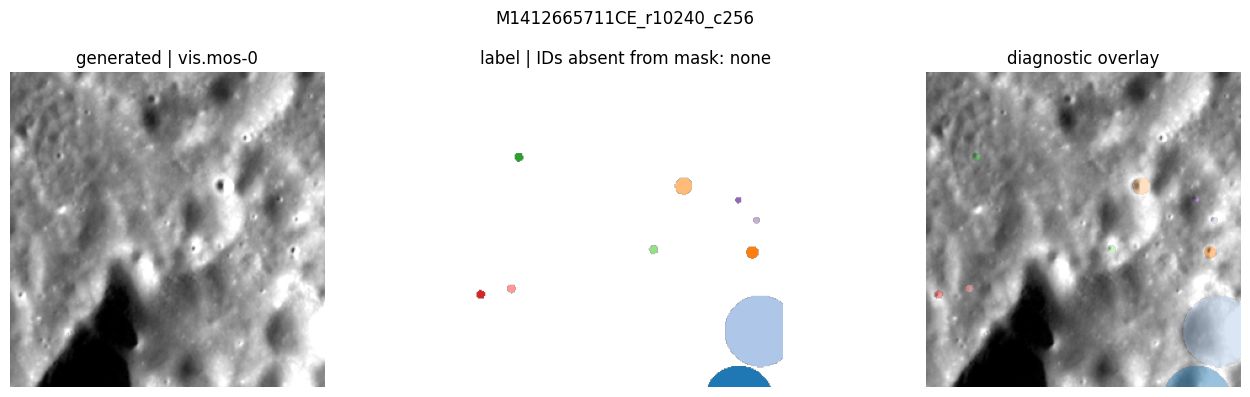

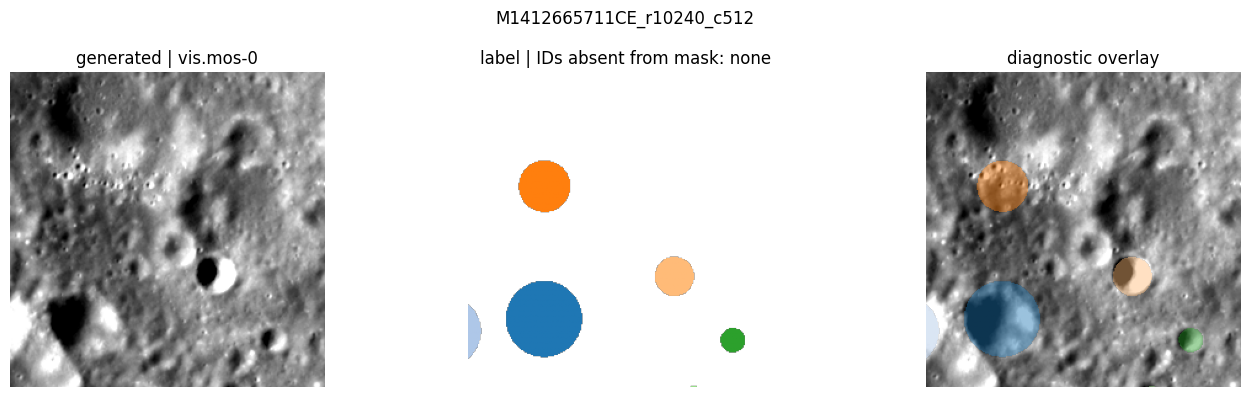

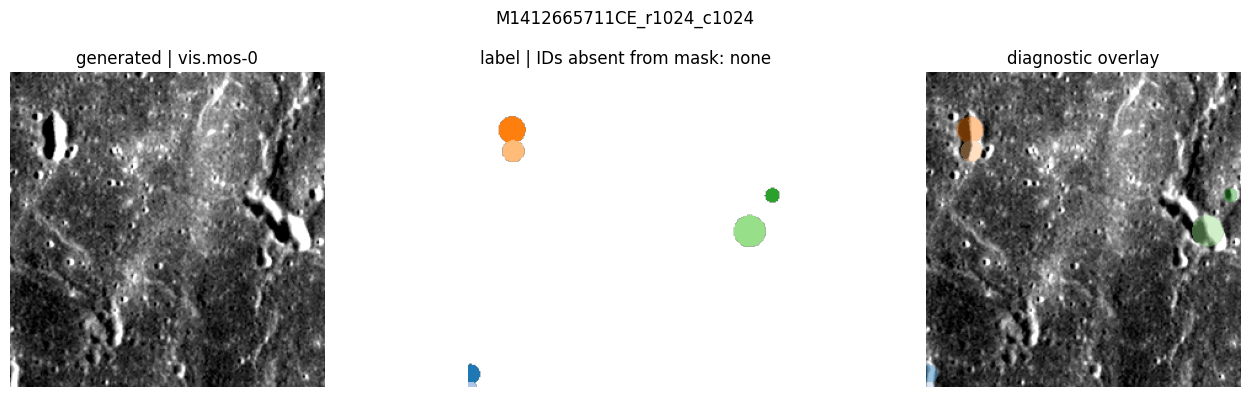

In [6]:
successful = [result for result in batch.results if result.status == "success"]
fully_valid, with_nodata, unknown_validity = [], [], []
dynamic_valid = []
dynamic_band_count = 7 if MODALITY == "wac" else 1
for result in successful:
    bands = (result.imagery_nodata or {}).get("bands", [])[:dynamic_band_count]
    if len(bands) == dynamic_band_count and all(b.get("invalid_count") == 0 for b in bands):
        dynamic_valid.append(result)
    invalid = (result.imagery_nodata or {}).get("union_invalid_count")
    if invalid == 0:
        fully_valid.append(result)
    elif invalid is not None and invalid > 0:
        with_nodata.append(result)
    else:
        unknown_validity.append(result)
nodata_summary = {
    "published_chips": len(successful),
    "chips_with_nodata_in_any_band": len(with_nodata),
    "fully_valid_chips": len(fully_valid),
    "unknown_validity_chips": len(unknown_validity),
    "fully_valid_dynamic_chips": len(dynamic_valid),
}
print("Imagery validity (all output bands):", nodata_summary)
(OUTPUT_ROOT / "nodata_summary.json").write_text(json.dumps(nodata_summary, indent=2) + "\n")
if not dynamic_valid:
    print("No chips verified as 100% valid across dynamic bands; no inspection plots generated.")
for result in dynamic_valid[:INSPECTION_SAMPLES]:
    plot_chip_result(result, display_band_index=0)